# **UK train data analysis and Financial Liability prediction**

In [714]:
import pandas as pd

In [715]:
df = pd.read_csv("railway.csv")

In [716]:
df.head(10)

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,NaN,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,NaN,No
6,1c74479d-85a4-4ba1-a607,2023-12-31,00:02:01,Station,Credit Card,Adult,Standard,Advance,2,London Euston,Oxford,2024-01-01,22:30:00,23:40:00,23:40:00,On Time,NaN,No
7,febf8dab-f808-46fa-bf2b,2023-12-31,01:35:18,Station,Contactless,Disabled,Standard,Advance,2,Liverpool Lime Street,Manchester Piccadilly,2024-01-01,00:00:00,00:30:00,00:30:00,On Time,NaN,No
8,01df916f-4291-41ec-a37d,2023-12-31,01:43:09,Station,Credit Card,NaN,Standard,Advance,37,London Euston,York,2024-01-01,00:00:00,01:50:00,02:07:00,Delayed,Signal Failure,No
9,a8cedba7-1923-459d-b046,2023-12-31,03:05:52,Online,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,01:30:00,02:30:00,02:30:00,On Time,NaN,No


In [717]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [718]:
df.isnull().sum()

Transaction ID             0
Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20918
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1880
Journey Status             0
Reason for Delay       27481
Refund Request             0
dtype: int64

In [719]:
df["Railcard"].unique()

array(['Adult', nan, 'Disabled', 'Senior'], dtype=object)

In [720]:
df["Reason for Delay"].unique()


array([nan, 'Signal Failure', 'Technical Issue', 'Weather Conditions',
       'Weather', 'Staffing', 'Staff Shortage', 'Signal failure',
       'Traffic'], dtype=object)

In [721]:
# 1. Standardize casing and remove hidden whitespaces
df['Reason for Delay'] = df['Reason for Delay'].str.strip().str.title()

# 2. Consolidate semantic duplicates into single clean categories
consolidation_map = {
    'Weather Conditions': 'Weather',
    'Staffing': 'Staff Shortage'
}
df['Reason for Delay'] = df['Reason for Delay'].replace(consolidation_map)
df['Reason for Delay'] = df['Reason for Delay'].fillna('On Time')

In [ ]:
# Converting the time and dates columns to datetime format.
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])
df['Arrival Time'] = pd.to_datetime(df['Arrival Time'], errors='coerce').dt.strftime('%H:%M:%S')
df['Departure Time'] = pd.to_datetime(df['Departure Time'], errors='coerce').dt.strftime('%H:%M:%S')
df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase'], errors='coerce').dt.strftime('%H:%M:%S')


/var/folders/92/jpt988fd0g92rw2ncx16x0fr0000gn/T/ipykernel_83424/2491769364.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival Time'] = pd.to_datetime(df['Arrival Time'], errors='coerce').dt.strftime('%H:%M:%S')
/var/folders/92/jpt988fd0g92rw2ncx16x0fr0000gn/T/ipykernel_83424/2491769364.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure Time'] = pd.to_datetime(df['Departure Time'], errors='coerce').dt.strftime('%H:%M:%S')
/var/folders/92/jpt988fd0g92rw2ncx16x0fr0000gn/T/ipykernel_83424/2491769364.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


In [723]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  object        
 1   Date of Purchase     31653 non-null  datetime64[ns]
 2   Time of Purchase     31653 non-null  object        
 3   Purchase Type        31653 non-null  object        
 4   Payment Method       31653 non-null  object        
 5   Railcard             10735 non-null  object        
 6   Ticket Class         31653 non-null  object        
 7   Ticket Type          31653 non-null  object        
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  object        
 10  Arrival Destination  31653 non-null  object        
 11  Date of Journey      31653 non-null  datetime64[ns]
 12  Departure Time       31653 non-null  object        
 13  Arrival Time         31653 non-

In [724]:
# Group by journey and railcard status to compare average ticket prices and after railcard apply, to ceck if the dataset is factually correct.
verification = df.groupby(['Departure Station', 'Arrival Destination', 'Ticket Class', 'Railcard'], dropna=False)['Price'].mean().unstack()
print(verification.head(10))

Railcard                                                      Adult  Disabled  \
Departure Station     Arrival Destination   Ticket Class                        
Birmingham New Street Coventry              First Class         NaN       NaN   
                                            Standard            NaN       NaN   
                      Edinburgh             First Class         NaN       NaN   
                                            Standard            NaN       NaN   
                      Liverpool Lime Street First Class   36.250000      34.0   
                                            Standard       4.850000       4.0   
                      London Euston         First Class         NaN       NaN   
                                            Standard      21.428571       NaN   
                      London Kings Cross    First Class         NaN      78.0   
                                            Standard            NaN      21.5   

Railcard                   

In [725]:
# 2. Safely fill the true NaN values to represent full-fare passengers
df['Railcard'] = df['Railcard'].fillna('No Railcard')

In [726]:
df.isnull().sum()

Transaction ID            0
Date of Purchase          0
Time of Purchase          0
Purchase Type             0
Payment Method            0
Railcard                  0
Ticket Class              0
Ticket Type               0
Price                     0
Departure Station         0
Arrival Destination       0
Date of Journey           0
Departure Time            0
Arrival Time              0
Actual Arrival Time    1880
Journey Status            0
Reason for Delay          0
Refund Request            0
dtype: int64

In [727]:
# Checking the Journey satatus types.
df['Journey Status'].unique()

array(['On Time', 'Delayed', 'Cancelled'], dtype=object)

In [728]:
import numpy as np

# If Journey Status is 'On Time' and Actual Arrival is missing, fill it with Arrival Time. 
# Otherwise, keep the original Actual Arrival Time.
df['Actual Arrival Time'] = np.where(
    df['Journey Status'] == 'On Time',
    df['Actual Arrival Time'].fillna(df['Arrival Time']),
    df['Actual Arrival Time']
)

In [729]:
# If Journey Status is cancelled then fill it with nan.
cancelled_mask = df['Journey Status'] == 'Cancelled'
df.loc[cancelled_mask, 'Actual Arrival Time'] = df.loc[cancelled_mask, 'Actual Arrival Time'].fillna('Not Applicable')
# df['Actual Arrival Time'] = df['Actual Arrival Time'].replace('Not Applicable', np.nan) # Safely revert into mathematically safe missing values

In [730]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,On Time,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,On Time,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,On Time,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,On Time,No


# EDA

In [731]:
import matplotlib.pyplot as plt
import seaborn as sns

In [732]:
df.describe(include="all")

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
count,31653,31653,31653,31653,31653,31653,31653,31653,31653.000000,31653,31653,31653,31653,31653,31653,31653,31653,31653
unique,31653,NaN,24351,2,3,4,2,3,NaN,12,32,NaN,96,203,624,3,6,2
top,da8a6ba8-b3dc-4677-b176,NaN,08:16:53,Online,Credit Card,No Railcard,Standard,Advance,NaN,Manchester Piccadilly,Birmingham New Street,NaN,18:45:00,19:05:00,Not Applicable,On Time,On Time,No
freq,1,NaN,6,18521,19136,20918,28595,17561,NaN,5650,7742,NaN,2598,1069,1880,27481,27481,30535
mean,NaN,2024-02-28 16:16:36.303667968,NaN,NaN,NaN,NaN,NaN,NaN,23.439200,NaN,NaN,2024-03-01 08:01:10.969576192,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2023-12-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2024-01-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,2024-01-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2024-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,2024-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2024-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,2024-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2024-04-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,267.000000,NaN,NaN,2024-04-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN


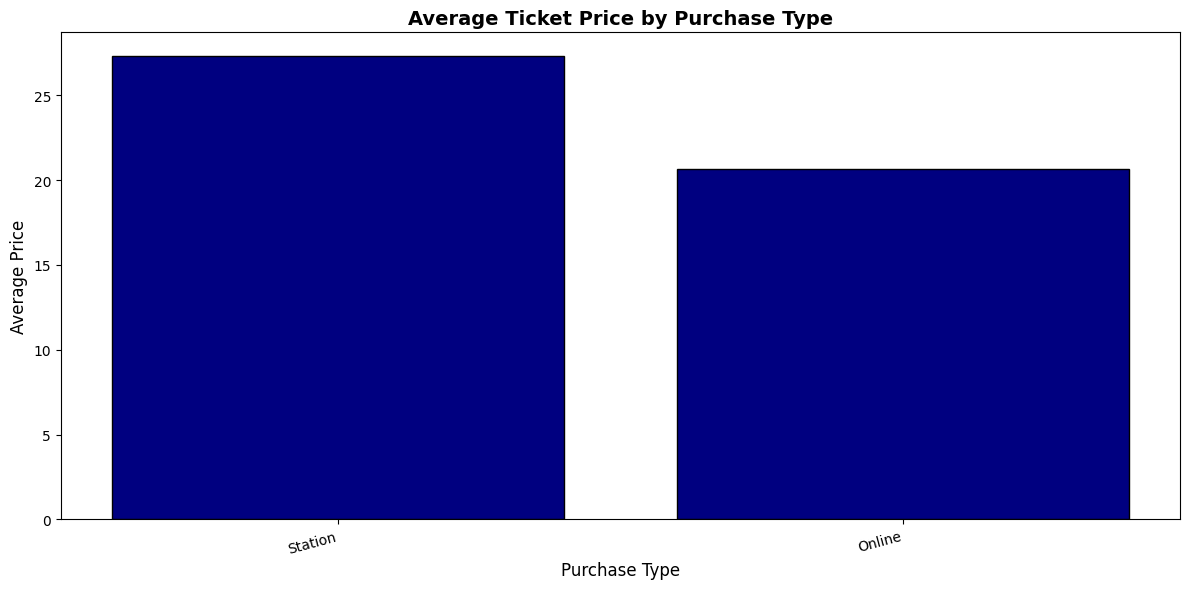

In [733]:
# Relation of Purchase type with price
import matplotlib.pyplot as plt

# 1. Aggregate the data by taking the mean price and sorting in descending order
df_grouped = df.groupby('Purchase Type')['Price'].mean().sort_values(ascending=False).reset_index()

# 2. Plot the sorted bars directly without using plt.figure()
plt.bar(df_grouped['Purchase Type'], df_grouped['Price'], color='navy', edgecolor='black')

# 3. Apply explicit labels and title
plt.xlabel('Purchase Type', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.title('Average Ticket Price by Purchase Type', fontsize=14, fontweight='bold')

# 4. Prevent overlapping or truncated text alignment
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# 5. Save the plot cleanly instead of using plt.show()
plt.savefig('purchase_type_vs_price.png', dpi=300)




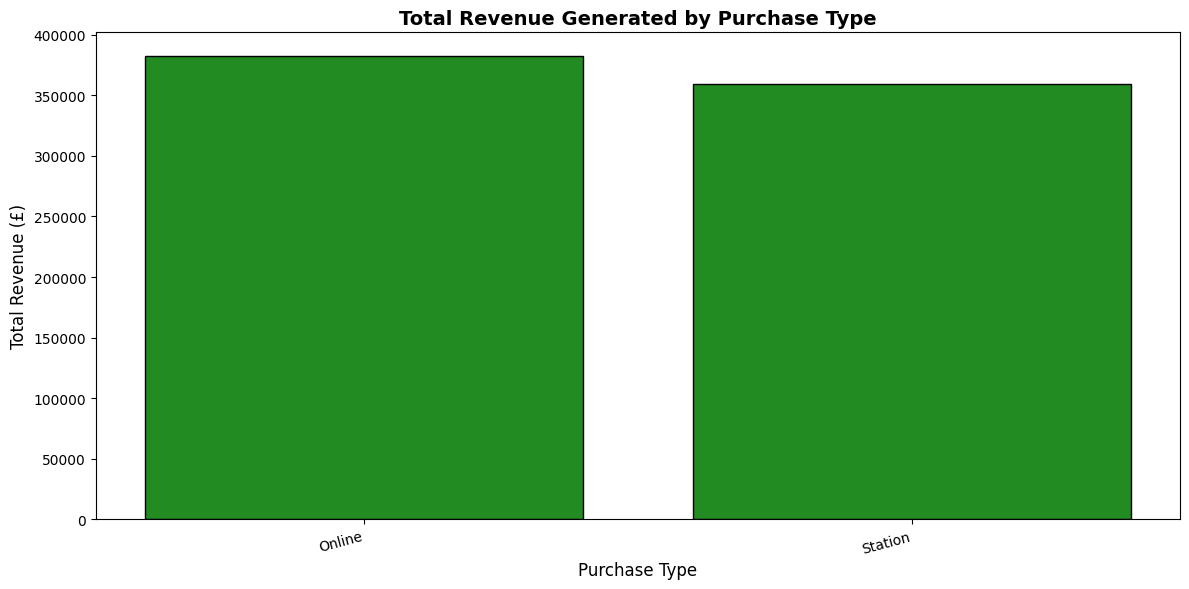

In [734]:
# Summing the prices gives total revenue per category
df_revenue = df.groupby('Purchase Type')['Price'].sum().sort_values(ascending=False).reset_index()

plt.bar(df_revenue['Purchase Type'], df_revenue['Price'], color='forestgreen', edgecolor='black')
plt.xlabel('Purchase Type', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.title('Total Revenue Generated by Purchase Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('purchase_type_vs_total_revenue.png', dpi=300)

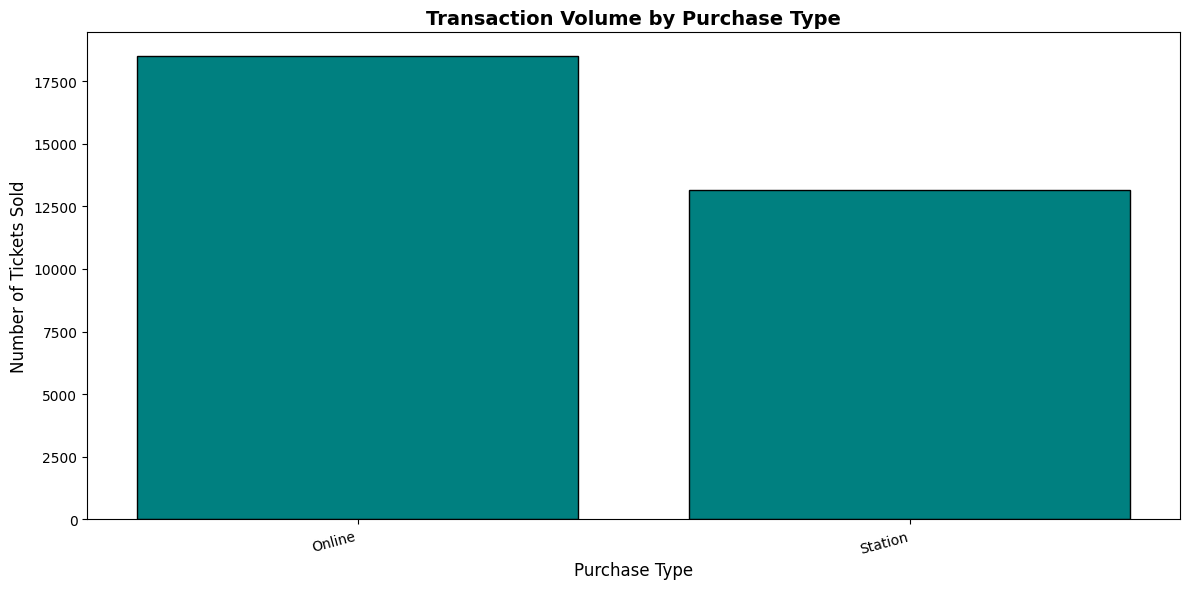

In [735]:
# Counting the occurrences gives the volume of sales
df_count = df.groupby('Purchase Type')['Price'].count().sort_values(ascending=False).reset_index()

plt.bar(df_count['Purchase Type'], df_count['Price'], color='teal', edgecolor='black')
plt.xlabel('Purchase Type', fontsize=12)
plt.ylabel('Number of Tickets Sold', fontsize=12)
plt.title('Transaction Volume by Purchase Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('purchase_type_vs_transaction_count.png', dpi=300)

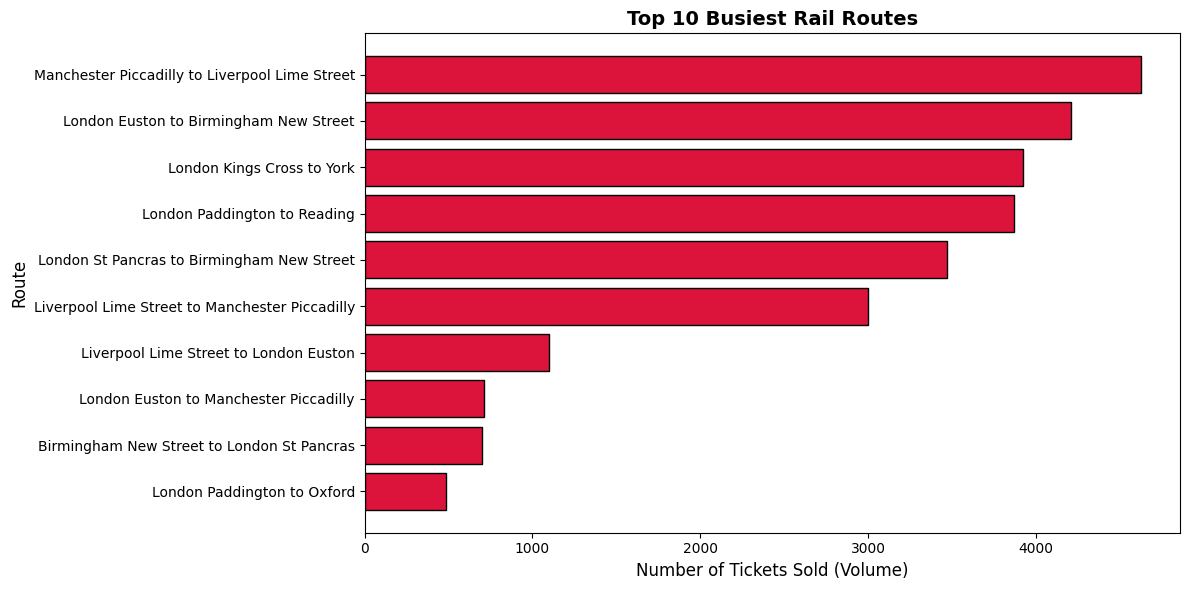

In [736]:
# Busiest route

# 1. Combine departure and arrival into a distinct Route column
df['Route'] = df['Departure Station'] + ' to ' + df['Arrival Destination']

# 2. Count the volume per route, sort, and isolate the top 10 busiest
# Using ascending=True ensures the highest volume route appears at the top of the horizontal chart
top_routes = df['Route'].value_counts().sort_values(ascending=True).tail(10)

# 3. Plot horizontal bars directly (this is mandatory for long route strings to prevent overlapping text)
plt.barh(top_routes.index, top_routes.values, color='crimson', edgecolor='black')

# 4. Apply explicit, non-overlapping labels
plt.xlabel('Number of Tickets Sold (Volume)', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.title('Top 10 Busiest Rail Routes', fontsize=14, fontweight='bold')

# 5. Fix margins and save cleanly without using plt.figure() or plt.show()
plt.tight_layout()
plt.savefig('busiest_routes.png', dpi=300)

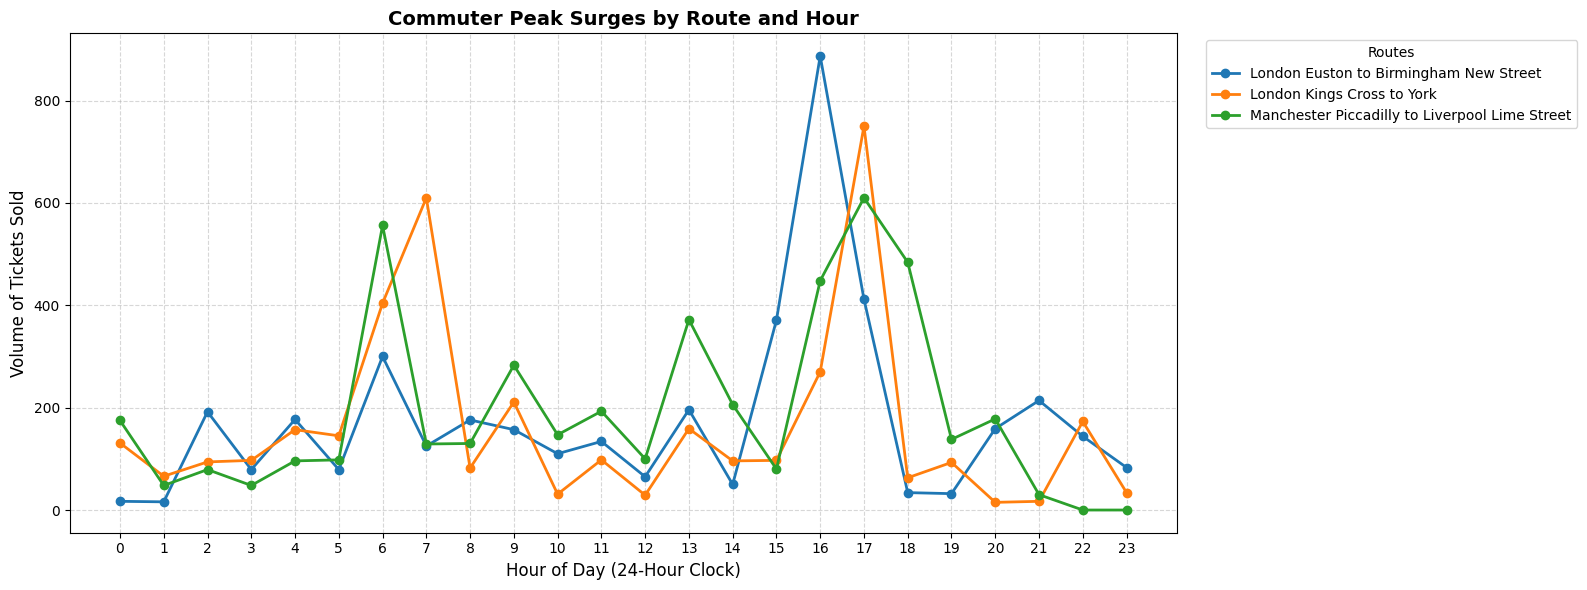

In [737]:
# 1. Consolidate stations into a unified Route column if not already done
plt.rcParams['figure.figsize'] = [16, 6]
df['Route'] = df['Departure Station'] + ' to ' + df['Arrival Destination']

# 2. Extract the hour from the string-formatted Departure Time column
df['Departure Hour'] = df['Departure Time'].str.split(':').str[0].astype(int)

# 3. Filter for the top 3 busiest routes to keep the visual clean and readable
top_3_routes = df['Route'].value_counts().nlargest(3).index
df_filtered = df[df['Route'].isin(top_3_routes)]

# 4. Group by hour and route, then unstack to create a plottable matrix
hourly_trends = df_filtered.groupby(['Departure Hour', 'Route']).size().unstack(fill_value=0)

# 5. Plot the lines sequentially without initializing a new figure canvas
for route in hourly_trends.columns:
    plt.plot(hourly_trends.index, hourly_trends[route], marker='o', linewidth=2, label=route)

# 6. Apply strict layout rules to avoid axis and legend truncation
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Volume of Tickets Sold', fontsize=12)
plt.title('Commuter Peak Surges by Route and Hour', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Routes', fontsize=10)
plt.tight_layout()

# 7. Export the visualization as an independent image file
plt.savefig('route_traffic_by_hour.png', dpi=300)

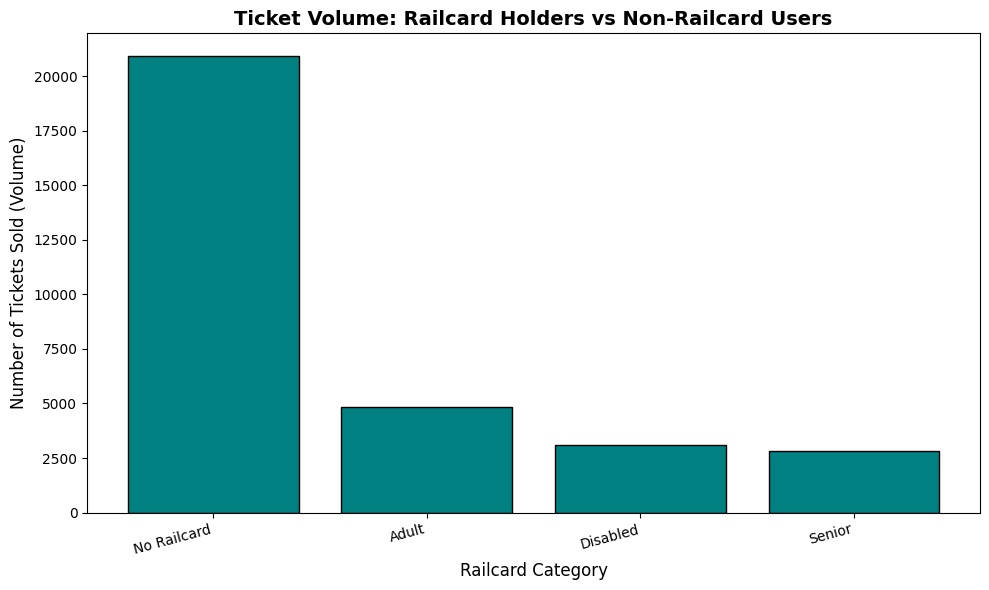

In [738]:
# 1. Set the global figure size for optimal visibility
plt.rcParams['figure.figsize'] = [10, 6]

# 2. Count occurrences of each category and sort in descending order
# This automatically puts the highest volume category (likely 'None') first
railcard_counts = df['Railcard'].value_counts().sort_values(ascending=False)

# 3. Plot the sorted bars directly without initializing a new figure canvas
plt.bar(railcard_counts.index, railcard_counts.values, color='teal', edgecolor='black')

# 4. Apply strict, explicit labeling
plt.xlabel('Railcard Category', fontsize=12)
plt.ylabel('Number of Tickets Sold (Volume)', fontsize=12)
plt.title('Ticket Volume: Railcard Holders vs Non-Railcard Users', fontsize=14, fontweight='bold')

# 5. Prevent text overlap or truncation
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# 6. Save the output cleanly as an independent file
plt.savefig('railcard_vs_non_railcard.png', dpi=300)

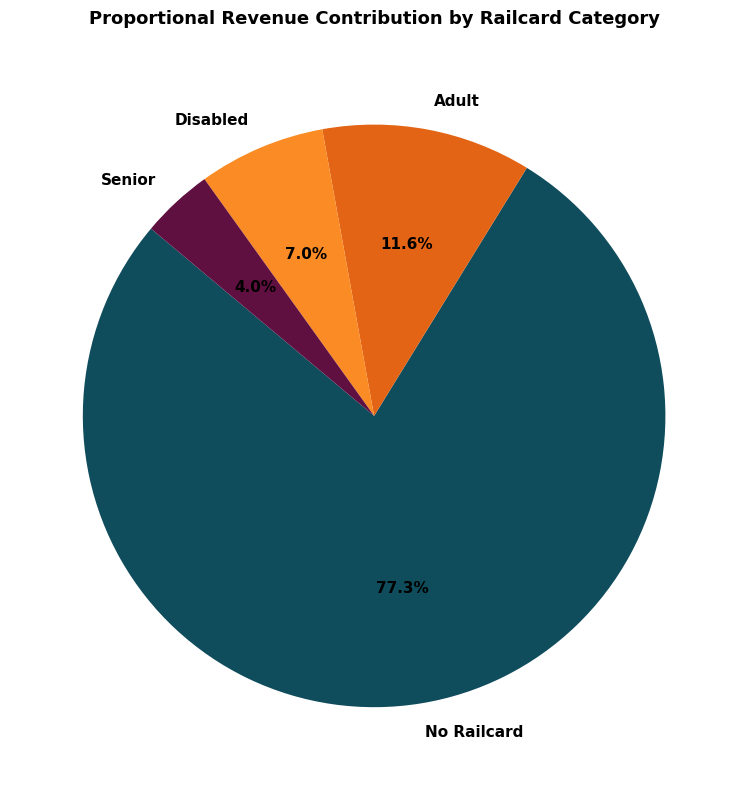

In [739]:
# 1. Set global canvas size for a balanced square layout
plt.rcParams['figure.figsize'] = [8, 8]

# 2. Aggregate total revenue by summing the ticket prices for each group
railcard_revenue = df.groupby('Railcard')['Price'].sum().sort_values(ascending=False)

# 3. Plot the pie chart directly onto the active axis context
plt.pie(
    railcard_revenue.values, 
    labels=railcard_revenue.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#0f4c5c', '#e36414', '#fb8b24', '#5f0f40'],
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# 4. Establish a clean title and tight bounding box
plt.title('Proportional Revenue Contribution by Railcard Category', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()

# 5. Save the output directly as an independent file
plt.savefig('railcard_revenue_share.png', dpi=300)

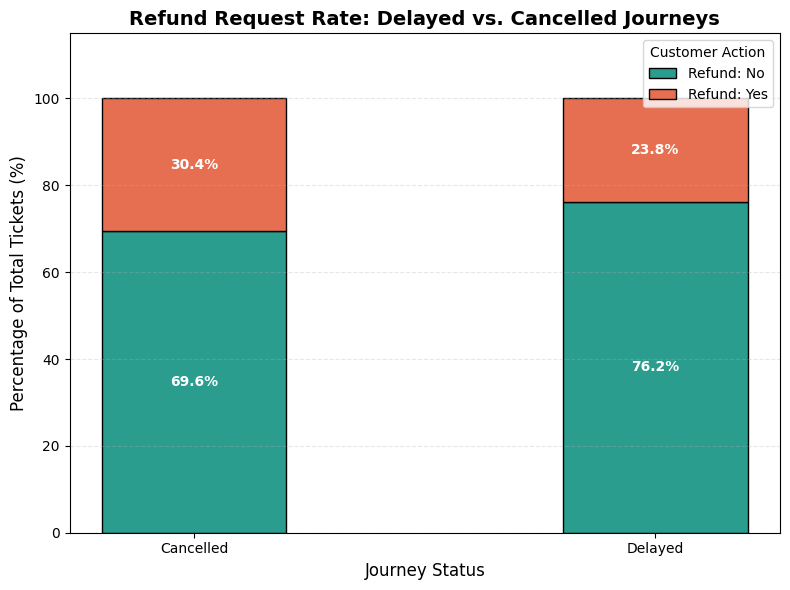

In [740]:
# Refund Request Rate (percentage of tickets refunded) exclusively for "Delayed" and "Cancelled" statuses using a stacked bar chart.

# 1. Set the global canvas size to keep the chart compact and readable
plt.rcParams['figure.figsize'] = [8, 6]

# 2. Filter the dataset to isolate only operational disruptions
df_disrupted = df[df['Journey Status'].isin(['Delayed', 'Cancelled'])]

# 3. Create a cross-tabulation and normalize by row to calculate exact percentages
# This handles whether your column contains 'Yes'/'No', 1/0, or true/false
refund_matrix = pd.crosstab(df_disrupted['Journey Status'], df_disrupted['Refund Request'], normalize='index') * 100

# 4. Plot the stacked bars and calculate text positions geometrically
bottom = np.zeros(len(refund_matrix))
colors = ['#2a9d8f', '#e76f51']  # High-contrast professional palette

for i, col in enumerate(refund_matrix.columns):
    # Store the drawn bars in a variable to extract their dimensions
    bars = plt.bar(
        refund_matrix.index, 
        refund_matrix[col], 
        bottom=bottom, 
        label=f"Refund: {col}", 
        color=colors[i % len(colors)], 
        edgecolor='black', 
        width=0.4
    )
    
    # Iterate through each physical bar segment to place the label
    for bar in bars:
        height = bar.get_height()
        
        # Only draw the text if the bar segment is larger than 3% to prevent text spilling
        if height > 3:
            # Calculate the exact center point of the segment
            x_pos = bar.get_x() + bar.get_width() / 2
            y_pos = bar.get_y() + (height / 2)
            
            # Place the text at the calculated coordinates
            plt.text(
                x_pos, 
                y_pos, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold',
                fontsize=10
            )
            
    # Update the bottom baseline for the next stacked category
    bottom += refund_matrix[col].values

# 5. Apply explicit structural labeling
plt.xlabel('Journey Status', fontsize=12)
plt.ylabel('Percentage of Total Tickets (%)', fontsize=12)
plt.title('Refund Request Rate: Delayed vs. Cancelled Journeys', fontsize=14, fontweight='bold')
plt.ylim(0, 115)  # Extra headroom to prevent the legend from clipping the data
plt.legend(loc='upper right', title='Customer Action')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# 6. Save the visualization directly to disk
plt.savefig('disruption_refund_rates.png', dpi=300)

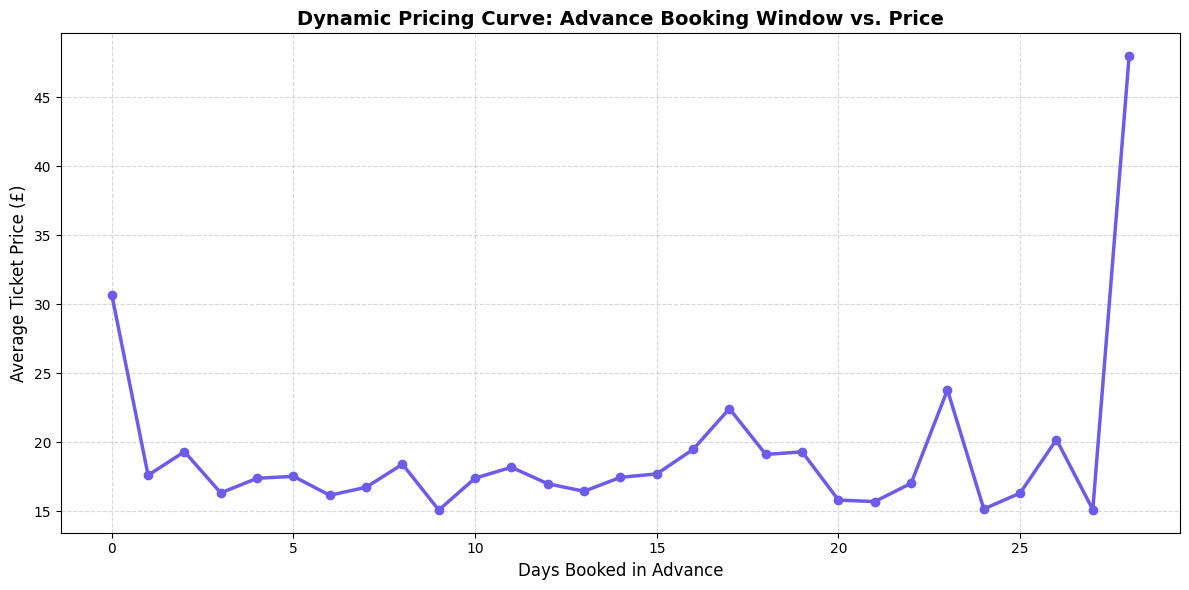

In [741]:
# The Advance Booking Window vs. Price

# 1. Maintain the ultra-wide layout for clear timeline visualization
plt.rcParams['figure.figsize'] = [12, 6]

# 2. Feature Engineering: Calculate the booking window in days
# Making sure both columns are treated as datetime objects
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Booking Window (Days)'] = (df['Date of Journey'] - df['Date of Purchase']).dt.days

# 3. Data Cleansing: Remove logical anomalies (buying a ticket after the train left)
df_clean = df[df['Booking Window (Days)'] >= 0]

# 4. Aggregation: Calculate the average price for each specific advance day
price_by_window = df_clean.groupby('Booking Window (Days)')['Price'].mean().reset_index()

# 5. Plot the trend directly without standard figure initialization
plt.plot(
    price_by_window['Booking Window (Days)'], 
    price_by_window['Price'], 
    marker='o', 
    color='#6c5ce7', 
    linewidth=2.5,
    markersize=6
)

# 6. Apply strict, clear labeling
plt.xlabel('Days Booked in Advance', fontsize=12)
plt.ylabel('Average Ticket Price (£)', fontsize=12)
plt.title('Dynamic Pricing Curve: Advance Booking Window vs. Price', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 7. Save the visualization cleanly
plt.savefig('booking_window_vs_price.png', dpi=300)

/var/folders/92/jpt988fd0g92rw2ncx16x0fr0000gn/T/ipykernel_83424/3658287624.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  refund_trends = df_timed.groupby('Delay Bracket')['Refund Request'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()


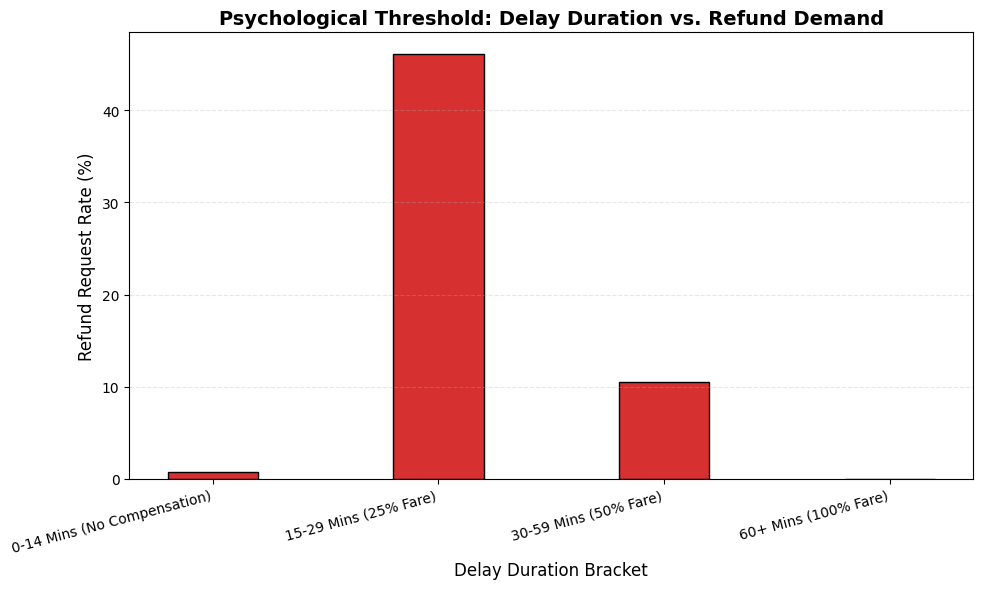

In [742]:
# Delay Duration vs. Refund Demand

# 1. Set global canvas size for clean horizontal distribution
plt.rcParams['figure.figsize'] = [10, 6]

# 2. Clean and Isolate data: Strip out cancelled journeys ('Not Applicable') to avoid calculation errors
df_timed = df[(df['Journey Status'].isin(['Delayed', 'On Time'])) & (df['Actual Arrival Time'] != 'Not Applicable')].copy()

# 3. Convert string time vectors into Timedeltas for mathematical subtraction
df_timed['Sched_Time'] = pd.to_timedelta(df_timed['Arrival Time'])
df_timed['Act_Time'] = pd.to_timedelta(df_timed['Actual Arrival Time'])

# 4. Calculate delay duration in minutes and clip early arrivals to zero
df_timed['Delay Minutes'] = (df_timed['Act_Time'] - df_timed['Sched_Time']).dt.total_seconds() / 60
df_timed['Delay Minutes'] = df_timed['Delay Minutes'].clip(lower=0)

# 5. Bin the durations using statutory UK Rail 'Delay Repay' compensation boundaries
bins = [0, 15, 30, 60, np.inf]
labels = ['0-14 Mins (No Compensation)', '15-29 Mins (25% Fare)', '30-59 Mins (50% Fare)', '60+ Mins (100% Fare)']
df_timed['Delay Bracket'] = pd.cut(df_timed['Delay Minutes'], bins=bins, labels=labels, include_lowest=True)

# 6. Calculate the exact percentage of passengers demanding refunds within each time tier
# This assumes 'Yes' marks a refund request; adjust string if your data uses 1 or True
refund_trends = df_timed.groupby('Delay Bracket')['Refund Request'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

# 7. Execute the plot directly on the active axis
plt.bar(refund_trends['Delay Bracket'], refund_trends['Refund Request'], color='#d63031', edgecolor='black', width=0.4)

# 8. Apply explicit structural typography and layout configurations
plt.xlabel('Delay Duration Bracket', fontsize=12)
plt.ylabel('Refund Request Rate (%)', fontsize=12)
plt.title('Psychological Threshold: Delay Duration vs. Refund Demand', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# 9. Save the visualization cleanly to disk
plt.savefig('delay_duration_vs_refund_rate.png', dpi=300)

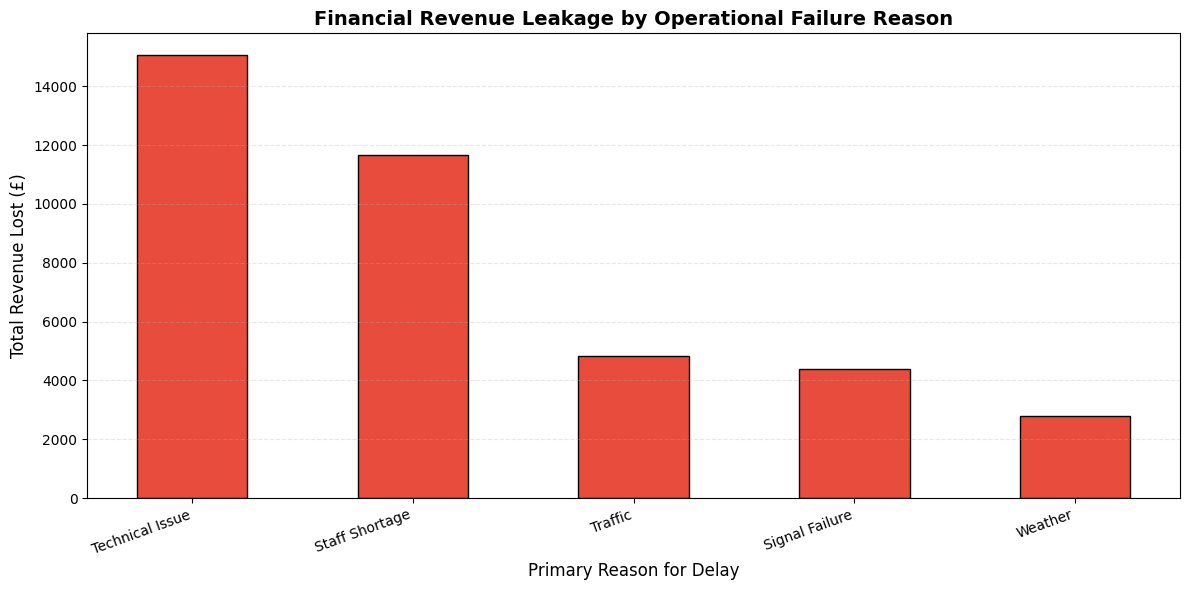

In [743]:
# Revenue Loss by Delay Reason

# 1. Standardize wide canvas dimensions
plt.rcParams['figure.figsize'] = [12, 6]

# 2. Filter for transactions where money was explicitly lost via a refund request
# This assumes 'Yes' indicates a refund; adjust if your column uses True or 1
df_refunds = df[df['Refund Request'] == 'Yes']

# 3. Aggregate total financial loss by summing the prices for each distinct delay reason
revenue_loss = df_refunds.groupby('Reason for Delay')['Price'].sum().sort_values(ascending=False).reset_index()

# 4. Plot the descending financial damage directly
plt.bar(revenue_loss['Reason for Delay'], revenue_loss['Price'], color='#e74c3c', edgecolor='black', width=0.5)

# 5. Apply explicit structural typography
plt.xlabel('Primary Reason for Delay', fontsize=12)
plt.ylabel('Total Revenue Lost (£)', fontsize=12)
plt.title('Financial Revenue Leakage by Operational Failure Reason', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

# 6. Export the independent file
plt.savefig('revenue_loss_by_reason.png', dpi=300)

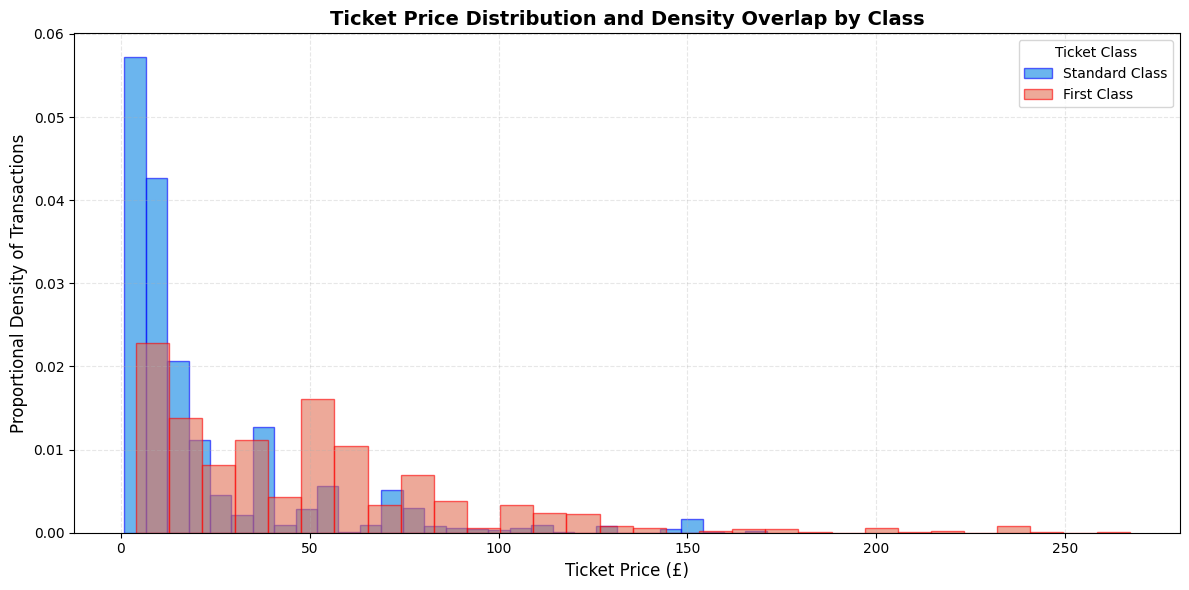

In [744]:
# Ticket Class Revenue Density

# 1. Maintain the expanded wide canvas to view long distributions clearly
plt.rcParams['figure.figsize'] = [12, 6]

# 2. Isolate fare distributions by ticket class
first_class_fares = df[df['Ticket Class'] == 'First Class']['Price']
standard_class_fares = df[df['Ticket Class'] == 'Standard']['Price']

# 3. Plot overlapping histograms using transparency (alpha) to see the intersection
# Density=True normalizes the counts so the shapes are directly comparable regardless of row count
plt.hist(standard_class_fares, bins=30, alpha=0.6, label='Standard Class', color='#0984e3', edgecolor='blue', density=True)
plt.hist(first_class_fares, bins=30, alpha=0.6, label='First Class', color='#e17055', edgecolor='red', density=True)

# 4. Apply rigorous charting metadata
plt.xlabel('Ticket Price (£)', fontsize=12)
plt.ylabel('Proportional Density of Transactions', fontsize=12)
plt.title('Ticket Price Distribution and Density Overlap by Class', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', title='Ticket Class')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# 5. Save the final file cleanly
plt.savefig('ticket_class_revenue_density.png', dpi=300)

# **Feature Engineering**

In [745]:
# 1. Isolate the dataset strictly to 'Delayed' journeys
df_delayed = df[df['Journey Status'] == 'Delayed'].copy()

# 2. Verify the structural drop was successful
print(f"Original row count: {len(df)}")
print(f"Delayed liability row count: {len(df_delayed)}")
print(f"Rows dropped: {len(df) - len(df_delayed)}")

Original row count: 31653
Delayed liability row count: 2292
Rows dropped: 29361


In [746]:
df_delayed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2292 entries, 1 to 31637
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Transaction ID         2292 non-null   object        
 1   Date of Purchase       2292 non-null   datetime64[ns]
 2   Time of Purchase       2292 non-null   object        
 3   Purchase Type          2292 non-null   object        
 4   Payment Method         2292 non-null   object        
 5   Railcard               2292 non-null   object        
 6   Ticket Class           2292 non-null   object        
 7   Ticket Type            2292 non-null   object        
 8   Price                  2292 non-null   int64         
 9   Departure Station      2292 non-null   object        
 10  Arrival Destination    2292 non-null   object        
 11  Date of Journey        2292 non-null   datetime64[ns]
 12  Departure Time         2292 non-null   object        
 13  Arrival

In [747]:

# 1. Convert string vectors to datetime objects for mathematical operations
# Using format='%H:%M:%S' assumes your data is strictly time-based. Use errors='coerce' to safely flag corrupt rows as NaN.
df_delayed['Sched_Arrival'] = pd.to_datetime(df_delayed['Arrival Time'], format='%H:%M:%S', errors='coerce')
df_delayed['Actual_Arrival'] = pd.to_datetime(df_delayed['Actual Arrival Time'], format='%H:%M:%S', errors='coerce')

# 2. Calculate continuous delay duration
df_delayed['Delay Minutes'] = (df_delayed['Actual_Arrival'] - df_delayed['Sched_Arrival']).dt.total_seconds() / 60

# 3. Handle the midnight crossing anomaly
# If a train is scheduled at 23:50 and arrives at 00:10, standard math yields -1420 minutes. 
# Adding 1440 minutes (24 hours) corrects this inversion.
df_delayed.loc[df_delayed['Delay Minutes'] < 0, 'Delay Minutes'] += 1440

# 4. Extract peak vs. off-peak integer hour
df_delayed['Departure Hour'] = df_delayed['Departure Time'].str.split(':').str[0].astype(int)

# 5. Drop the raw string columns and intermediate calculations to prevent XGBoost string errors
columns_to_drop = [
    'Arrival Time', 
    'Actual Arrival Time', 
    'Departure Time', 
    'Sched_Arrival', 
    'Actual_Arrival',
    'Departure Station',
    'Arrival Destination',
    'Date of Journey',
    'Date of Purchase',
    'Time of Purchase',
    'Transaction ID',
    'Payment Method',
    'Reason for Delay',
    'Journey Status'
]
df_delayed = df_delayed.drop(columns=columns_to_drop)

# 6. Verify output integrity
print(df_delayed[['Delay Minutes', 'Departure Hour']].head())
print(f"\nRemaining object columns to One-Hot Encode: {df_delayed.select_dtypes(include=['object']).columns.tolist()}")

    Delay Minutes  Departure Hour
1             5.0               9
8            17.0               0
20           31.0              11
26           24.0              14
45           11.0               3

Remaining object columns to One-Hot Encode: ['Purchase Type', 'Railcard', 'Ticket Class', 'Ticket Type', 'Refund Request', 'Route']


In [748]:
df_delayed.head()

,Purchase Type,Railcard,Ticket Class,Ticket Type,Price,Refund Request,Route,Departure Hour,Booking Window (Days),Delay Minutes
1,Station,Adult,Standard,Advance,23,No,London Kings Cross to York,9,16,5.0
8,Station,No Railcard,Standard,Advance,37,No,London Euston to York,0,1,17.0
20,Station,Adult,Standard,Advance,7,Yes,Birmingham New Street to Manchester Piccadilly,11,1,31.0
26,Online,Senior,First Class,Advance,34,Yes,Oxford to Bristol Temple Meads,14,1,24.0
45,Station,No Railcard,First Class,Advance,134,No,Manchester Piccadilly to London Euston,3,1,11.0


# **Model training and deployement**

In [749]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier


# Separate Target (Y) and convert to binary
y = df_delayed['Refund Request'].map({'Yes': 1, 'No': 0})
X_raw = df_delayed.drop(columns=['Refund Request'])

# Categorical Encoding
# This converts all remaining text columns into binary 1s and 0s
X = pd.get_dummies(X_raw, drop_first=True)

# Train-Test Split (80/20)
# 'stratify=y' ensures the 20% test set has the exact same proportion of refunds as the 80% training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle the Imbalance
# Calculate the exact ratio of No Refunds to Yes Refunds to penalize the algorithm for missing a claim
majority_class_count = (y_train == 0).sum()
minority_class_count = (y_train == 1).sum()
imbalance_ratio = majority_class_count / minority_class_count
print(f"majority_class_count :{majority_class_count}")
print(f"minority_class_count : {minority_class_count}")
print(f"imbalance_ratio: {imbalance_ratio}")
print("")
# Initialize and Train the XGBoost Model
# max_depth=4 prevents the model from memorizing your small 2.2K row dataset
model = XGBClassifier(
    scale_pos_weight=imbalance_ratio, 
    max_depth=4, 
    learning_rate=0.1, 
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate the Model's True Performance
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

majority_class_count :1396
minority_class_count : 437
imbalance_ratio: 3.194508009153318

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       350
           1       0.90      0.95      0.93       109

    accuracy                           0.97       459
   macro avg       0.94      0.96      0.95       459
weighted avg       0.97      0.97      0.97       459



In [750]:
import joblib

# 1. Create a Cascading Route Dictionary
# Maps every Departure Station to a list of ONLY its valid Arrival Destinations
valid_routes = df.groupby('Departure Station')['Arrival Destination'].unique().apply(list).to_dict()

# 2. Extract Exact Railcards
valid_railcards = df['Railcard'].dropna().unique().tolist()

# 3. Create a Pricing Lookup Table
# Calculates the median historical price for a specific route + class + type combination
price_lookup = df.groupby(['Departure Station', 'Arrival Destination', 'Ticket Class', 'Ticket Type','Railcard'])['Price'].median().to_dict()

# 4. Package and export this metadata for the Streamlit app to consume
app_metadata = {
    'routes': valid_routes,
    'railcards': valid_railcards,
    'pricing': price_lookup
}
joblib.dump(app_metadata, 'app_metadata.pkl')

['app_metadata.pkl']

In [751]:

# Save the trained model
joblib.dump(model, 'refund_liability_model.pkl')

# Save the exact list of encoded feature columns the model expects
expected_columns = list(X.columns)
joblib.dump(expected_columns, 'model_columns.pkl')

['model_columns.pkl']